### MTCNN y FaceNet Face Detection

In [23]:
# Mostrar solo los frames de la webcam en una ventana de OpenCV
import cv2

capture = cv2.VideoCapture(1)

if not capture.isOpened():
    capture = cv2.VideoCapture(0)

while True:
    ret, frame = capture.read()
    if not ret:
        print("No se pudo leer un frame de la webcam.")
        break

    cv2.imshow("Webcam", frame)

    key = cv2.waitKey(1) & 0xFF
    if key == ord('q') or key == 27:  # q o ESC para salir
        break

capture.release()
cv2.destroyAllWindows()

In [8]:
def detect_faces(detector, image, min_confidence=None):

    # detector.detect from facenet-pytorch returns boxes and probabilities
    boxes, probs = detector.detect(image)
    results = []
    if boxes is not None:
        for box, prob in zip(boxes, probs):
            if min_confidence is not None and prob < min_confidence:
                continue
            x1, y1, x2, y2 = [int(b) for b in box]
            width, height = x2 - x1, y2 - y1
            # Format to match OpenCV/MTCNN classic layout
            results.append({
                'box': [max(0, x1), max(0, y1), width, height],
                'confidence': prob
            })
    return results  # list of dicts with 'box' and 'confidence'

import cv2
from facenet_pytorch import MTCNN
import torch

# capture one frame 
def capture_frame(video_capture):
    ret, frame = video_capture.read()
    if not ret:
        raise RuntimeError("Failed to capture frame from camera.")
    return frame

# test

capture = cv2.VideoCapture(1)
fframe = capture_frame(capture)
# torch gpu test
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo para detección: {device}")
detector = MTCNN(keep_all=True, device=device)
faces = detect_faces(detector, fframe)
print(f"Caras detectadas: {len(faces)}")





Usando dispositivo para detección: cuda:0
Caras detectadas: 1


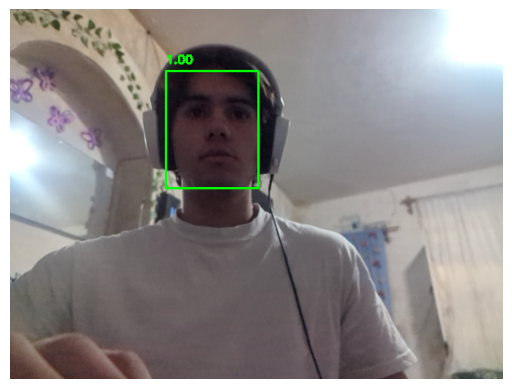

In [12]:
# Plot faces on the image
import matplotlib.pyplot as plt
frame_copy = fframe.copy()

for face in faces:
    x, y, w, h = face['box']
    confidence = face['confidence']
    cv2.rectangle(frame_copy, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(frame_copy, f"{confidence:.2f}", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

import matplotlib.pyplot as plt
plt.imshow(cv2.cvtColor(frame_copy, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [ ]:
import numpy as np
import os
from facenet_pytorch import MTCNN, InceptionResnetV1

# Create an inception resnet (in eval mode):
resnet = InceptionResnetV1(pretrained='vggface2').eval()

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo para extracción de embeddings: {device}")

# Move model to device
resnet = resnet.to(device)

embeddings = []
img_h, img_w = fframe.shape[:2]

for face in faces:
    x, y, w, h = face['box']
    x1 = max(0, int(x)); y1 = max(0, int(y))
    x2 = min(img_w, x1 + max(1, int(w))); y2 = min(img_h, y1 + max(1, int(h)))
    if x2 <= x1 or y2 <= y1:
        continue

    face_bgr = fframe[y1:y2, x1:x2]
    face_rgb = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2RGB)
    face_resized = cv2.resize(face_rgb, (160, 160))
    face_tensor = torch.from_numpy(face_resized).permute(2, 0, 1).float().to(device)
    face_tensor = (face_tensor / 255.0 - 0.5) / 0.5  # normalize to [-1,1]

    with torch.no_grad():
        emb = resnet(face_tensor.unsqueeze(0))
    embeddings.append(emb.cpu().numpy().reshape(-1))

embeddings = np.vstack(embeddings) if embeddings else np.empty((0, resnet.embedding_size if hasattr(resnet, "embedding_size") else 512)) # 
print("Embeddings shape:", embeddings.shape)



Usando dispositivo para extracción de embeddings: cuda:0
Embeddings shape: (1, 512)


In [6]:
import joblib

# Load the trained classifier
classifier_path = os.path.join( 'model', 'face_classifier.joblib')
classifier = joblib.load(classifier_path)

# Load the label encoder
label_encoder_path = os.path.join( 'model', 'label_encoder.joblib')
label_encoder = joblib.load(label_encoder_path)

def predict_identity(classifier, label_encoder, embedding):
    yhat_class = classifier.predict(embedding.reshape(1, -1))
    yhat_prob = classifier.predict_proba(embedding.reshape(1, -1))
    class_index = yhat_class[0]
    class_probability = yhat_prob[0, class_index]
    predicted_label = label_encoder.inverse_transform(yhat_class)[0]
    return predicted_label, class_probability

pred_label, pred_prob = predict_identity(classifier, label_encoder, embeddings[0])

# Draw results on the image
for face in faces:
    x, y, w, h = face['box']
    cv2.rectangle(fframe, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(
        fframe,
        f"{pred_label} ({pred_prob:.2f})",
        (x, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        (0, 255, 0),
        2,
    )


/home/ulises-calderon/miniconda3/envs/face-gpu312/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.0.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/ulises-calderon/miniconda3/envs/face-gpu312/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.0.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


ValueError: X has 512 features, but SVC is expecting 128 features as input.

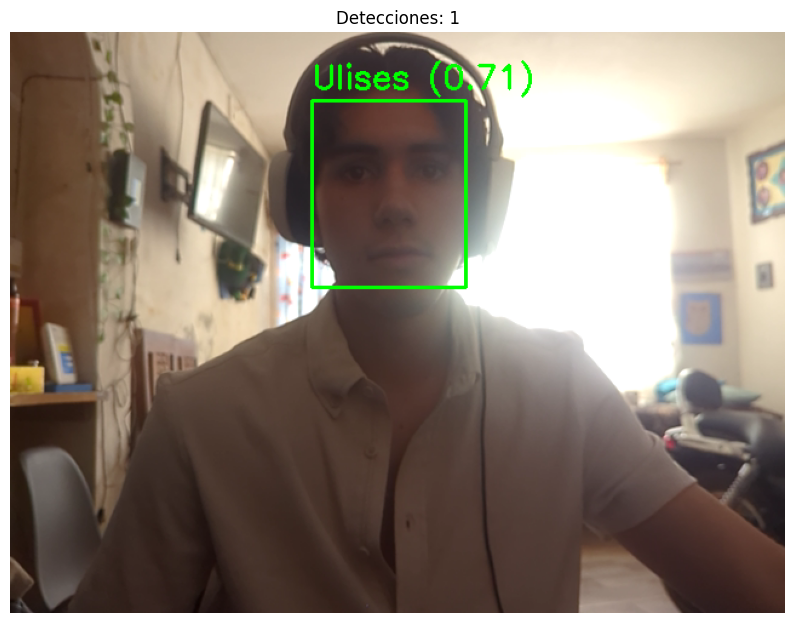

In [ ]:
# Plot the final image with detections and predictions
import matplotlib.pyplot as plt
img = cv2.cvtColor(fframe, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('off')
plt.title(f"Detecciones: {len(predictions)}")
plt.show()